In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','nature','no-latex'])

In [3]:
data_path = r"C:\Users\yy3\BWCloud\Manuscript files\NbSe2 figure drafts\figure 4\Lift off\2025-01-10_17-16-01_2024-07-07_21-20-24_PODMR_Hahn_echo_Z_lift_off_scan_A-H12-13_NbSe2_S4_rot_2.0K_70mT_Bnv_sFC_Z_lift_off_Set_E_analysed.pickle"
with open(data_path, 'rb') as pickle_file:
    data = pickle.load(pickle_file)

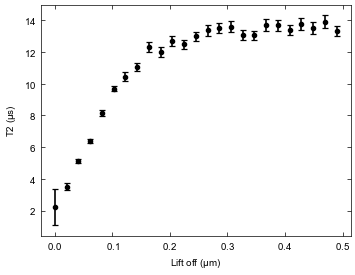

In [7]:
import os
import matplotlib as mpl
plt.rcParams.update({'mathtext.default':  'regular' })
plt.rcParams.update({'svg.fonttype':  'none' })


filepath = os.path.split(data_path)[0]
save = True
s1,s2 = 0, 25
x = data['Fit']['Z_lift_off'][s1:s2]*1e6
plt.figure(figsize=(4,3))
plt.rcParams["font.family"] = 'Arial'
plt.errorbar(x=x, y=data['Fit']['T2'][s1:s2]*1e6,
                 yerr=data['Fit']['T2_err'][s1:s2]*1e6, fmt='o', color='black',
                 capsize=2, capthick=0.9,
                 elinewidth=1.2)
plt.xlabel('Lift off ($\\mu$m)')
plt.ylabel(r'T2 ($\mu$s)')
plt.minorticks_off()
if save:
    with open(filepath+f'_jupyter_plot_t2_vec.svg', 'wb') as f:
        plt.savefig(f,format='svg',dpi=3000)

plt.show()

# plt.figure(figsize=(3,3))
# plt.rcParams["font.family"] = 'Helvetica'
# plt.plot(x,data['Fit']['Field']*1e3, 'o', color='black')
# plt.xlabel('Lift off ($\\mu$m)')
# plt.ylabel('B$_{\\mathrm{NV}}$ (mT)')
# plt.minorticks_off()
# if save:
#     with open(filepath+f'_jupyter_plot_field_vec.svg', 'wb') as f:
#         plt.savefig(f,format='svg',dpi=3000)

# plt.show()

# plt.figure(figsize=(3,3))
# plt.rcParams["font.family"] = 'Helvetica'
# plt.errorbar(x=x, y=data['Fit']['Contrast'],
#                  yerr=data['Fit']['Contrast_err'], fmt='o', color='black',
#                  capsize=2, capthick=0.9,
#                  elinewidth=1.2)
# plt.xlabel('Lift off ($\\mu$m)')
# plt.ylabel('Contrast (perc.)')
# plt.minorticks_off()
# if save:
#     with open(filepath+f'_jupyter_plot_contr_vec.svg', 'wb') as f:
#         plt.savefig(f,format='svg',dpi=3000)

# plt.show()

In [24]:
data_path = r"C:\Users\Sreehari Jayaram\BWCloud\Manuscript files\NbSe2 figure drafts\figure 4\Temp sweep\Summary_Set_C.pickle"
with open(data_path, 'rb') as pickle_file:
    data = pickle.load(pickle_file)

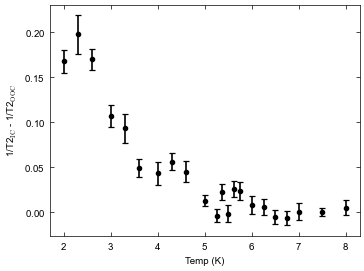

In [25]:
import os
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties import umath

filepath = os.path.split(data_path)[0]
save = True

x = data['temp']['data']

y_OOC = unumpy.uarray(data['t2_OOC']['data'], data['t2_OOC']['err'])
y_IC = unumpy.uarray(data['t2_IC']['data'], data['t2_IC']['err'])

y = 1/y_IC - 1/y_OOC 

plt.figure(figsize=(4,3))
plt.rcParams["font.family"] = 'Arial'
plt.rcParams.update({'svg.fonttype':  'none' })

plt.errorbar(x=x, y=unumpy.nominal_values(y),
                 yerr=unumpy.std_devs(y), fmt='o', color='black',
                 capsize=2, capthick=0.9,
                 elinewidth=1.2)
plt.xlabel('Temp (K)')
plt.ylabel('1/T2$_{\mathrm{IC}}$ - 1/T2$_{\mathrm{OOC}}$')
plt.minorticks_off()
if save:
    with open(filepath+f'_jupyter_plot_t2_temp_vec.svg', 'wb') as f:
        plt.savefig(f,format='svg',dpi=3000)

plt.show()

T2 in contact and retracted

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model
from scipy.ndimage import gaussian_filter1d
import scienceplots
plt.style.use(['science','nature','no-latex'])
import matplotlib as mpl
plt.rcParams.update({'mathtext.default':  'regular' })
plt.rcParams.update({'svg.fonttype':  'none' })
import os
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties import umath

def stretched_exp_decay(x, amplitude, offset, lifetime, beta):
    """ Function of a bare exponential decay.

    @param numpy.array x: 1D array as the independent variable - e.g. time
    @param float lifetime: constant lifetime

    @return: bare exponential decay function: in order to use it as a model
    """
    return amplitude * np.exp(-np.power(x / lifetime, beta)) + offset

def estimate_decayexponentialstretched(x_axis, data, params):
    """ Provide an estimation for initial values for a stretched exponential decay with offset.

    @param numpy.array x_axis: 1D axis values
    @param numpy.array data: 1D data, should have the same dimension as x_axis.
    @param lmfit.Parameters params: object includes parameter dictionary which
                                    can be set

    @return tuple (error, params):

    Explanation of the return parameter:
        int error: error code (0:OK, -1:error)
        Parameters object params: set parameters of initial values
    """

    # Smooth very radically the provided data, so that noise fluctuations will
    # not disturb the parameter estimation.
    std_dev = 10
    data_smoothed = gaussian_filter1d(data, std_dev)

    # calculation of offset, take the last 10% from the end of the data
    # and perform the mean from those.
    offset = data_smoothed[-max(1, int(len(x_axis) / 10)):].mean()

    # substraction of the offset and correction of the decay behaviour
    # (decay to a bigger value or decay to a smaller value)
    if data_smoothed[0] < data_smoothed[-1]:
        data_smoothed = offset - data_smoothed
        ampl_sign = -1
    else:
        data_smoothed = data_smoothed - offset
        ampl_sign = 1

    if data_smoothed.min() <= 0:
        data_smoothed = data_smoothed - data_smoothed.min()

    # Take all values up to the standard deviation, the remaining values are
    # more disturbing the estimation then helping:
    for stop_index in range(0, len(x_axis)):
        if data_smoothed[stop_index] <= data_smoothed.std():
            break

    data_level_log = np.log(data_smoothed[0:stop_index])

    # make a polynomial fit with a second order polynom on the remaining data:
    poly_coef = np.polyfit(x_axis[0:stop_index], data_level_log, deg=2)

    # obtain the values from the polynomical fit
    lifetime = 1 / np.sqrt(abs(poly_coef[0]))
    amplitude = np.exp(poly_coef[2])

    # Include all the estimated fit parameter:
    params['amplitude'].set(value=amplitude * ampl_sign)
    params['offset'].set(value=offset)

    min_lifetime = 2 * (x_axis[1] - x_axis[0])
    params['lifetime'].set(value=lifetime, min=min_lifetime)

    # as an arbitrary starting point:
    params['beta'].set(value=2, min=0)

    return params




data_path = r"G:\Data\Projects\YBCO\S1 with diamond membrane\Hahn echo comparison Meissner region\20241205-1100-51_Hecho-alt-phased_A-H12-13_YBCO_80K_5mT_OOP_FC_OOC_pulsed_measurement.dat"
data_OOC = np.loadtxt(data_path).T

data_path = r"G:\Data\Projects\YBCO\S1 with diamond membrane\Hahn echo comparison Meissner region\20241205-1113-34_Hecho-alt-phased_A-H12-13_YBCO_80K_5mT_OOP_FC_IC_pulsed_measurement.dat"
data_IC = np.loadtxt(data_path).T

TypeError: 'NoneType' object is not subscriptable

In [8]:
filepath = os.path.split(data_path)[0]
save = True

gmodel = Model(stretched_exp_decay)
params = gmodel.make_params()

data_used = data_OOC
x_axis=data_used[0]
data_sig0=unumpy.uarray(data_used[1], data_used[3])
data_sig1=unumpy.uarray(data_used[2], data_used[4])
data_sig = data_sig0-data_sig1
data_sig = data_sig/unumpy.nominal_values(data_sig).max()

data = unumpy.nominal_values(data_sig)
params = estimate_decayexponentialstretched(x_axis, data, params)
result = gmodel.fit(data, params, x=x_axis)

sweep_dense = np.linspace(x_axis[0], x_axis[-1], 500)
temp = gmodel.eval(result.params, x=sweep_dense)

plt.figure(figsize=(4,3))
plt.rcParams["font.family"] = 'Arial'
plt.errorbar(x=x_axis*1e6, y=data,
                 yerr=unumpy.std_devs(data_sig), fmt='o', color="#8b0000",
                 capsize=2, capthick=0.9,
                 elinewidth=1.2, label="Retracted")
plt.xlabel('Time ($\\mu$s)')
plt.ylabel(r'Signal (arb.u.)')
plt.minorticks_off()
plt.plot(sweep_dense*1e6, temp, 'k-')


data_used = data_IC
x_axis=data_used[0]
data_sig0=unumpy.uarray(data_used[1], data_used[3])
data_sig1=unumpy.uarray(data_used[2], data_used[4])
data_sig = data_sig0-data_sig1
data_sig = data_sig/unumpy.nominal_values(data_sig).max()

data = unumpy.nominal_values(data_sig)
params = estimate_decayexponentialstretched(x_axis, data, params)
result = gmodel.fit(data, params, x=x_axis)

sweep_dense = np.linspace(x_axis[0], x_axis[-1], 500)
temp = gmodel.eval(result.params, x=sweep_dense)
plt.rcParams["font.family"] = 'Arial'
plt.errorbar(x=x_axis*1e6, y=data,
                 yerr=unumpy.std_devs(data_sig), fmt='o', color="#0001b8",
                 capsize=2, capthick=0.9,
                 elinewidth=1.2, label="In contact")
plt.xlabel('Time ($\\mu$s)')
plt.ylabel(r'Signal (arb.u.)')
plt.minorticks_off()
plt.plot(sweep_dense*1e6, temp, 'k-')
plt.legend()
if save:
    with open(filepath+f'_jupyter_plot_t2_IC_OOC_vec.svg', 'wb') as f:
        plt.savefig(f,format='svg',dpi=3000)

plt.show()

NameError: name 'unumpy' is not defined